## 1. Charger et prétraiter l'ensemble de données MNIST

In [1]:
# Importer les bibliothèques nécessaires
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Charger l'ensemble de données MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Normalisation des valeurs des pixels

In [2]:
# Normaliser les valeurs des pixels de l'image pour qu'elles soient comprises entre 0 et 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Forme de x_train après normalisation: {x_train.shape}, valeurs min: {np.min(x_train)}, max: {np.max(x_train)}")

Forme de x_train après normalisation: (60000, 28, 28), valeurs min: 0.0, max: 1.0


### Conversion des étiquettes au format encodé one-hot

In [3]:
# Convertir les étiquettes au format encodé one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Forme de y_train après encodage one-hot: {y_train.shape}")

Forme de y_train après encodage one-hot: (60000, 10)


### Afficher des exemples d'images avec leurs étiquettes correspondantes

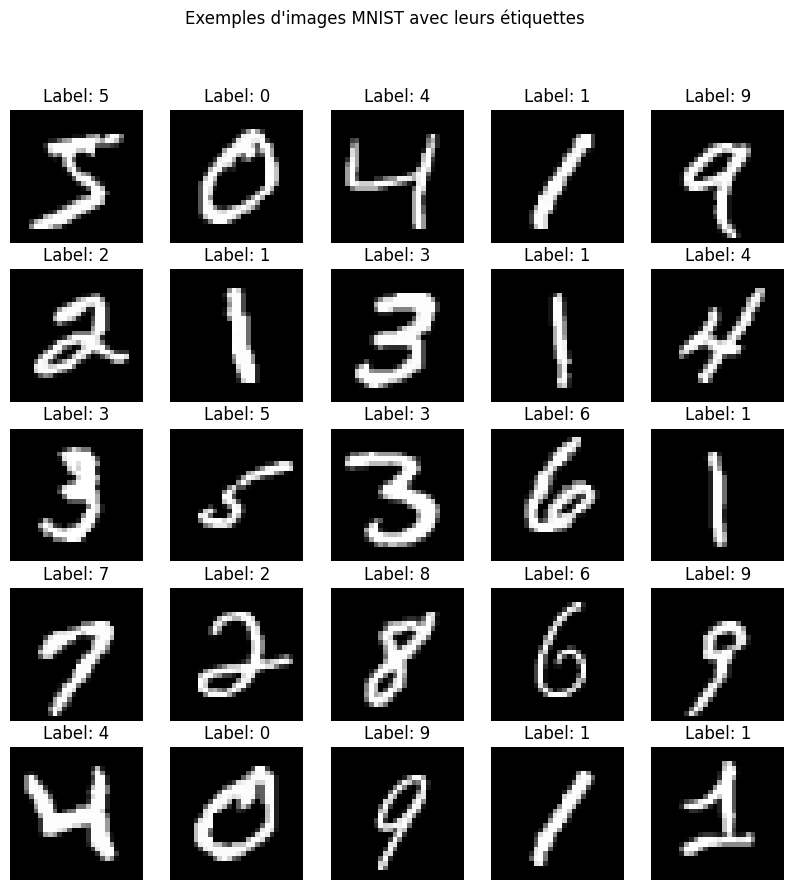

In [4]:
# Fonction pour convertir les étiquettes one-hot en entier
def one_hot_to_int(one_hot_array):
    return np.argmax(one_hot_array)

# Afficher des exemples d'images avec leurs étiquettes correspondantes
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {one_hot_to_int(y_train[i])}")
    plt.axis('off')
plt.suptitle('Exemples d\'images MNIST avec leurs étiquettes')
plt.show()

## 2. Construire un réseau neuronal entièrement connecté

### Définir un modèle séquentiel

In [5]:
# Définir le modèle séquentiel
model = tf.keras.models.Sequential([
    # Aplatir les images d'entrée 28x28 en un seul vecteur
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    # Première couche cachée avec activation ReLU
    tf.keras.layers.Dense(128, activation='relu'),
    # Deuxième couche cachée avec activation ReLU
    tf.keras.layers.Dense(64, activation='relu'),
    # Couche de sortie avec activation Softmax pour la classification multiclasse (10 chiffres)
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compiler le modèle

In [6]:
# Compiler le modèle en utilisant l'optimiseur Adam, l'entropie croisée catégorielle comme fonction de perte et la précision comme métrique d'évaluation.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Afficher un résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)